# X-venue noise concordance

`frag.xvenue_noise_concord` — **Hold**. Same-day noise levels can move together without implying a tradable edge or FEI/Epps claim.


In [1]:
from pathlib import Path
import json
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path('/home/dev/srv/ares-microstructure/research/books/mn_tuwrv')
OUT = BOOK / 'out'
FIGS = OUT / 'desk_synthesis' / 'figs'
sys.path.insert(0, str(BOOK.parents[2]))  # research/

def jload(rel):
    return json.loads((OUT / rel).read_text())

def show_fig(name, caption=None):
    p = FIGS / name
    if caption:
        display(Markdown(f'**{caption}** — `{p.relative_to(BOOK)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'*missing figure* `{p}` — run `scripts/build_notebook_figs.py`'))

bc = jload('blocker_close/blocker_close.json')
gc = jload('gap_close/gap_close.json')
mc = jload('monte_carlo/mc_summary.json')
p2 = jload('pass2/pass2_gates.json')
print('BOOK', BOOK)
print('figs', sorted(p.name for p in FIGS.glob('*.png')))


BOOK /home/dev/srv/ares-microstructure/research/books/mn_tuwrv
figs ['fig_clock_medians.png', 'fig_gate_counts.png', 'fig_mc_rmse_ladder.png', 'fig_mid_venue_split.png', 'fig_noise_vs_spread.png', 'fig_noise_vs_spread_gap_close.png', 'fig_ratio_hist.png', 'fig_tob_coverage.png', 'fig_tsrv_oos.png', 'signal_board.png']


pass2 xvenue gate: {'decision': 'Hold', 'why': 'close_noise_days=5/6 (rel range <35%)'}


,day,symbol,venue,noise_std
0,2026-09-10,ETH,hyperliquid,0.000082
1,2026-09-10,ETH,deribit,0.000056
2,2026-09-11,ETH,hyperliquid,0.000066
3,2026-09-11,ETH,deribit,0.000054
4,2026-09-12,ETH,hyperliquid,0.000023
5,2026-09-12,ETH,deribit,0.000025
6,2026-09-13,ETH,hyperliquid,0.000015
7,2026-09-13,ETH,deribit,0.000043
8,2026-09-14,ETH,hyperliquid,0.000060
9,2026-09-14,ETH,deribit,0.000065


,day,symbol,n_venues,rel_range,ns_hyperliquid,ns_deribit,ns_kraken
0,2026-09-10,BTC,2,0.806966,0.000105,0.000045,NaN
1,2026-09-10,ETH,2,0.379408,0.000082,0.000056,NaN
2,2026-09-11,BTC,2,0.033853,0.000035,0.000034,NaN
3,2026-09-11,ETH,2,0.201504,0.000066,0.000054,NaN
4,2026-09-12,BTC,2,0.223116,0.000015,0.000019,NaN
5,2026-09-12,ETH,2,0.080824,0.000023,0.000025,NaN
6,2026-09-13,BTC,2,0.891480,0.000009,0.000022,NaN
7,2026-09-13,ETH,2,0.942752,0.000015,0.000043,NaN
8,2026-09-14,BTC,2,0.078418,0.000040,0.000044,NaN
9,2026-09-14,ETH,2,0.081429,0.000060,0.000065,NaN


frac rel_range < 0.35: 0.8809523809523809


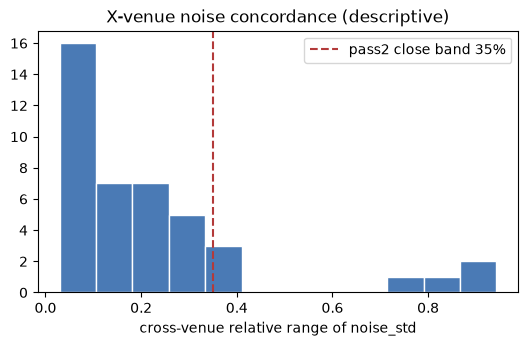

# X-venue noise — EXP_REPORT (Pass 2.5)

- Close-noise symbol-days: 26/28
- `frag.xvenue_noise_concord` → **Hold** (level concordance ≠ edge).



In [2]:
print('pass2 xvenue gate:', p2.get('frag.xvenue_noise_concord'))
# same-day noise concordance from blocker panel
rows = [r for r in bc['rows'] if r.get('ok')]
# pivot noise_std by day×symbol if calendar present
recs = []
for r in rows:
    ns = (r.get('calendar') or {}).get('noise_std', np.nan)
    if np.isfinite(ns):
        recs.append({'day': r['day'], 'symbol': r['symbol'], 'venue': r['venue'], 'noise_std': ns})
df = pd.DataFrame(recs)
display(df.head(20))
# pairwise day concordance: relative range across venues
conc = []
for (day, sym), g in df.groupby(['day','symbol']):
    if g['venue'].nunique() < 2:
        continue
    vals = g['noise_std'].to_numpy()
    rel = (vals.max() - vals.min()) / max(np.median(vals), 1e-12)
    conc.append({'day': day, 'symbol': sym, 'n_venues': int(g['venue'].nunique()), 'rel_range': float(rel),
                 **{f"ns_{r.venue}": float(r.noise_std) for r in g.itertuples()}})
cdf = pd.DataFrame(conc)
display(cdf)
if len(cdf):
    print('frac rel_range < 0.35:', float((cdf['rel_range'] < 0.35).mean()))
    fig, ax = plt.subplots(figsize=(6.2,3.4))
    ax.hist(cdf['rel_range'], bins=12, color='#4a7ab5', edgecolor='white')
    ax.axvline(0.35, color='#b33a3a', ls='--', label='pass2 close band 35%')
    ax.set_xlabel('cross-venue relative range of noise_std'); ax.legend()
    ax.set_title('X-venue noise concordance (descriptive)')
    plt.show()
print((BOOK/'chapters/xvenue_noise/EXP_REPORT.md').read_text()[:1500])
